# 1. Imports and Reads

In [147]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import astropy.units as u
from tabulate import tabulate
from statsmodels.tsa.seasonal import STL
from src.preprocessing.preprocess_dataset import PODPreprocessor
from scipy.signal import find_peaks
from astropy.time import Time
from astropy.coordinates import GCRS, ITRS, CartesianRepresentation, Angle
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from poliastro.twobody import Orbit
from poliastro.bodies import Earth
from poliastro.earth import EarthSatellite
from poliastro.earth.plotting import GroundtrackPlotter
from poliastro.util import time_range
from poliastro.twobody.sampling import EpochsArray
from sunpy.net import Fido, attrs as a

In [148]:
# various paths
BASE_PATH = '../../Zenodo/data/2024-05-01_2024-05-14/'
RESULTS_PATH = '../../Zenodo/results/2024-05-01_2024-05-14/'
CONFIG_PATH = BASE_PATH + '/configs/POD/config_pretty.json'
LST_PATH = BASE_PATH + '/raw/POD/OUT'
PROCESSED_PATH = BASE_PATH + 'processed/'
ICME_PATH = BASE_PATH + 'CMEs/'
STYLE_PATH = "../workflow/manuscript.mplstyle"
ICME_DURATIONS = json.load(open(ICME_PATH + '/ICME_durations_all_catalogs.json'))
maneuvers = pd.read_csv(BASE_PATH + 'maneuvers/maneuvers.csv')

# satellite configuration
config = json.load(open(CONFIG_PATH))
sats = list(config.keys())
SAT_PATHS = [BASE_PATH + sat + '.csv' for sat in sats]
altitudes = {s['name']: s['altitude'] for s in config.values()}
best_shifts_combined = json.load(open(f'{RESULTS_PATH}shifts/best_shifts_all_modes.json', 'r'))

# target variables
target = 'Orbital Decay Rate (m/day)'
target_with_maneuvers = 'Orbital Decay Rate (m/day) [maneuvers]'

# data frequency
fs = 1 / pd.Timedelta('30s').total_seconds()

# create results directories if they don't exist
for dir in ['cors', 'figures', 'disturbance_annotations']:
    if not os.path.exists(f'{RESULTS_PATH}{dir}'):
        os.makedirs(f'{RESULTS_PATH}{dir}')

In [149]:
dfs = {}
df_all_stats = None
for i, sat in enumerate(SAT_PATHS):
    satellite = config[sats[i]]['name']
    df = pd.read_csv(PROCESSED_PATH + sat.split('/')[-1])
    df.index = pd.to_datetime(df['time'])
    activity_levels = pd.read_csv(f"{RESULTS_PATH}/shifts/activity_levels_{satellite}.csv", index_col=0)
    activity_levels.index = pd.to_datetime(activity_levels.index)
    df['Altitude (km)'] = (df['a [m]'] - 6371000)/1000
    df['activity_level'] = activity_levels['activity_level']
    df['lowess_decay_trend'] = activity_levels['lowess_decay_trend']

    dfs[satellite] = df

    df_stats= df[[target, 'Altitude (km)']].agg(['min', 'max', 'mean', 'median', 'std'])
    df_stats['Maneuver Count'] = df['Maneuver'].sum()
    df_stats['Satellite'] = satellite
    if df_all_stats is None:
        df_all_stats = df_stats
    else:
        df_all_stats = pd.concat([df_all_stats, df_stats])

df_all_stats['Function'] = df_all_stats.index.values
df_all_stats.index = df_all_stats.reset_index()

df_lasp = pd.read_csv(f'{BASE_PATH}/raw/LATIS.csv')
df_lasp['time'] = pd.to_datetime(df_lasp['time'])
df_lasp.set_index('time', inplace=True)

Reading raw Local Solar Time (LST) data generated via the Bernese GNSS software (for retrieving all of the mean orbital parameters which were not saved in the processed datasets).

In [150]:
def get_skiprows(file_path):
    with open(file_path, 'r') as f:
        skiprows = 0
        while f.readline() != '\n':
            skiprows += 1
    return skiprows

dfs_lst = {}
for sat in sats:
    satellite_name = config[sat]['name']
    files_for_satellite = [
        file for file in os.listdir(LST_PATH) if sat in file
    ]
    files_for_satellite.sort()

    file_paths = [os.path.join(LST_PATH, file) for file in files_for_satellite]
    dataframes = []
    for file in file_paths:
        dataframes.append(pd.read_fwf(file, colspecs='infer',
                          skiprows=get_skiprows(file)))
    df_sat = pd.concat(dataframes, ignore_index=True)
    df_sat['MJD'] = Time(df_sat['MJD'].values, format='mjd').to_datetime()
    df_sat.rename({'MJD': 'time'}, axis=1, inplace=True)
    df_sat.sort_values(by='time', inplace=True)
    df_sat.set_index('time', inplace=True)
    df_sat.index = df_sat.index.map(lambda dt: dt.round('30s'))
    df_sat = df_sat.interpolate()
    df_sat['mean_altitude'] = (df_sat['a [m]'] - 6371000)/1000
    dfs_lst[satellite_name] = df_sat

# computing pair phase differences
pairs = [
    ('Swarm A', 'Swarm C'),
    ('Sentinel 2A', 'Sentinel 2B'),
    ('Sentinel 3A', 'Sentinel 3B'),
    ('GRACE-FO C', 'GRACE-FO D'),
]
mean_pair_phase_diffs =  {}

for (pair1, pair2) in pairs:
    phase_diff_raw = np.array(dfs_lst[pair1]['u_sat [deg]']) - np.array(dfs_lst[pair2]['u_sat [deg]'])
    phase_diff_raw = (phase_diff_raw + 180) % 360 - 180
    pair_diff_raw = np.mean(np.abs(phase_diff_raw)) * np.sign(np.mean(phase_diff_raw))
    mean_pair_phase_diffs[pair1] = pair_diff_raw
    mean_pair_phase_diffs[pair2] = - pair_diff_raw
    print(f'{pair1} - {pair2} mean pair phase difference: {pair_diff_raw:.2f} degrees')

Swarm A - Swarm C mean pair phase difference: -0.44 degrees
Sentinel 2A - Sentinel 2B mean pair phase difference: 179.80 degrees
Sentinel 3A - Sentinel 3B mean pair phase difference: -138.78 degrees
GRACE-FO C - GRACE-FO D mean pair phase difference: 1.52 degrees


# 2. Utils

## Geomagnetically disturbed intervals

In [151]:
def get_time_ranges_for_geomagnetically_disturbed_intervals(extend_end=True):
    # using original data that was not interpolated for peak finding
    # otherwise, due to the step-like interpolation it's more difficult
    kp_series = df_lasp['kp_value'].dropna()[::-1]

    # find peaks in Kp values above threshold
    peaks, _ = find_peaks(kp_series.values, height=5, distance=10)
    peak_times = kp_series.iloc[peaks].index

    kp_series = kp_series[::-1]
    peak_times = peak_times[::-1]

    # identify time ranges from peak Kp to minimum Kp between peaks
    time_ranges_of_interest = []

    for i in range(len(peak_times) - 1):
        start = peak_times[i]
        next_peak = peak_times[i + 1]

        interval_kp = kp_series.loc[start:next_peak]
        if interval_kp.empty:
            print("empty")
            continue

        min_kp_time = interval_kp.idxmin()

        # only consider the minima after the peaks
        if min_kp_time > start:
            time_ranges_of_interest.append((start, min_kp_time))

    if len(peak_times) >= 1:
        last_peak = peak_times[-1]
        final_end = kp_series.index[kp_series.values > 3][-1]
        if final_end > last_peak:
            time_ranges_of_interest.append((last_peak, final_end))

    # prolong start to end of previous interval
    for i in range(1, len(time_ranges_of_interest)):
        t0 = time_ranges_of_interest[i-1][1]
        t1 = time_ranges_of_interest[i][1]
        time_ranges_of_interest[i] = (t0, t1)

    time_ranges_of_interest[0] = (df_lasp.iloc[0].name, time_ranges_of_interest[0][1])
    if extend_end:
        time_ranges_of_interest[-1] = (time_ranges_of_interest[-1][0], df_lasp.iloc[-1].name)
    return time_ranges_of_interest

In [152]:
# Kp thresholds for geomagnetic storm intensity (NOAA)
geomagnetic_storm_levels = {
    "G0 (Quiet to Unsettled)": (0.0, 4.9),
    "G1 (Minor)": (5.0, 5.9),
    "G2 (Moderate)": (6.0, 6.9),
    "G3 (Strong)": (7.0, 7.9),
    "G4 (Severe)": (8.0, 8.9),
    "G5 (Extreme)": (9.0, 9.0)
}

def classify_kp(kp_float):
    for level, (low, high) in geomagnetic_storm_levels.items():
        if low <= kp_float <= high:
            return level
    return "Unknown"

In [153]:
def compute_min_bz_max_decay_timings(data1, start, end, target, mode="symh"):
    time_mask = (data1.index >= start) & (data1.index <= end)

    decay_series = data1.loc[time_mask][target]
    symh_series = data1.loc[time_mask]['SymH (Omni)']
    bz_series = data1.loc[time_mask]['Bz GSE']
    kp_series = data1.loc[time_mask]['Kp (LASP)']

    if decay_series.empty or symh_series.empty or bz_series.empty:
        return None

    # find reference time
    min_bz_val = bz_series.min()
    min_bz_time = bz_series.idxmin()

    symh_after_bz = symh_series.loc[min_bz_time:]
    if symh_after_bz.empty:
        return None

    min_symh_val = symh_after_bz.min()
    min_symh_time = symh_after_bz.idxmin()

    if mode == "symh":
        ref_time = min_symh_time
        decay_after = decay_series.loc[decay_series.index >= ref_time]
    elif mode == "bz":
        ref_time = min_bz_time
        decay_after = decay_series.loc[decay_series.index >= ref_time]
    else:
        raise ValueError("mode must be 'symh' or 'bz'")

    if decay_after.empty:
        return None

    max_decay = decay_after.max()
    max_decay_time = decay_after.idxmax()

    return {
        "Start": start,
        "End": end,
        "Max Kp": kp_series.max(),
        "Min SymH": min_symh_val,
        "Min Bz": min_bz_val,
        "Ref Time": ref_time,
        "Median Decay": decay_series.median(),
        "Max Decay": max_decay,
        "Time of Max Decay": max_decay_time,
        "Time Difference": max_decay_time - ref_time,
        "Altitude": int(data1.loc[time_mask]['mean_altitude'].mean()),
        "Storm Level": classify_kp(kp_series.max())
    }

## Plotting

In [154]:
# some colors that seem reasonable to distinguish for different eye diseases. Surprisingly, default 'colorblind' palettes are not really good in all cases.

CB = {
    "lightblue": "#c0d4f5",
    "blue": "#7b9ff9",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#9B4F86",
    "gray": "#666666",
    "black": "#000000"
}

In [155]:
def apply_plotting_style(global_apply: bool = True, palette="deep"):
    if global_apply:
        sns.set_theme(style="whitegrid", rc={"grid.alpha": 0.25, "axes.grid": True})
        plt.style.use(str(STYLE_PATH))
        plt.rcParams['pdf.fonttype'] = 42
        sns.set_palette(palette)
        return None
    else:
        return plt.style.context(str(STYLE_PATH))

def add_panel_labels(axes, place='right', max_len=None):
    if not max_len:
        max_len = len(axes)

    panel_labels = [chr(ord('a') + i) for i in range(max_len)]
    for i in range(max_len):
        axes[i].text(0.98 if place =='right' else 0.02, 0.95, f"({panel_labels[i]})", transform=axes[i].transAxes, fontsize=10,fontweight="bold", va="top", ha=place)

In [156]:
def plot_aggregated_satellites_correlation_spread_all_regions(best_shifts, thr='0', col_cor='|avg B|', method='pearson', cor_thr=0.65, regions = ['Quiet', 'Medium', 'Strong'], pal=None, show=False):
    apply_plotting_style()
    response_time_correlations = []
    lags = list(range(0, 30*60, 5))

    for f in regions:
        for sat, df in dfs.items():
            cors_for_sat = best_shifts[col_cor][thr][f][sat][method][col_cor][2]
            alt_group = 'Low' if altitudes[sat] < 600 else 'High'
            if altitudes[sat]  > 1000:
                continue
            for cor, lag in zip(cors_for_sat, lags):
                data = {'satellite': sat, 'cor_for_lag': cor, 'lag' : lag, 'Altitude Group' : alt_group, 'Region': f}
                response_time_correlations.append(data)

    response_time_correlations = pd.DataFrame(response_time_correlations)

    palette = pal if pal != None else sns.color_palette("colorblind", n_colors=len(regions))

    fig, axes = plt.subplots(1, 2, figsize=(6.8, 2), sharey=True)
    axes = axes.flatten()
    for k, group in enumerate(['Low', 'High']):
        ax = axes[k]

        altitude_group = response_time_correlations[response_time_correlations['Altitude Group'] == group].copy()
        altitude_group['Region'] = pd.Categorical(
            altitude_group['Region'],
            categories=regions,
            ordered=True
        )

        altitude_group.ffill(inplace=True)

        agg = altitude_group.groupby(['lag', 'Region'])['cor_for_lag'].agg(['mean', 'std']).reset_index()

        sns.lineplot(data=agg, x='lag', y='mean', hue='Region', palette=palette, ax=ax)

        xticks = range(0, 48*60 + 1, 240)
        xlabels = [str(x//60) for x in xticks]
        plt.xticks(ticks=xticks, labels=xlabels)

        sign = -1 if col_cor == '|avg B|' else 1
        for i, region in enumerate(agg['Region'].unique()):
            group_df = agg[agg['Region'] == region]
            if col_cor == '|avg B|':
                lag_best = group_df.loc[group_df['mean'].idxmax(), 'lag']
                if np.nanmax(group_df['mean']) > cor_thr:
                    ax.axvline(lag_best, linestyle='--', color=palette[i])
                    ax.text(lag_best - (2 * 60), sign * 0.8 + i*0.15, f'{lag_best} minutes', fontsize=7, color=palette[i], va='center', bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor=palette[i], linewidth=0.5))

                    # print(f"Std {region}; {group}: {group_df.loc[group_df['mean'].idxmax(), 'std']}")
            else:
                if np.min(group_df['mean']) < cor_thr:
                    lag_best = group_df.loc[group_df['mean'].idxmin(), 'lag']
                    ax.axvline(lag_best, linestyle='--', color=palette[i])
                    ax.text(lag_best - (2 * 60), sign * 0.8 + i*0.15, f'{lag_best} minutes', fontsize=7, color=palette[i], va='center', bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor=palette[i], linewidth=0.5))

                    
            lower = (group_df['mean'] - group_df['std'])
            upper = (group_df['mean'] + group_df['std'])

            group_df = agg[agg['Region'] == region]
            ax.fill_between(
                group_df['lag'],
                lower,
                upper,
                alpha=0.25,
                color=palette[regions.index(region)],
                edgecolor='none',
            )
        ax.title.set_text(f"s/c {'below' if group == 'Low' else 'above'} 600 km")
        thr_text = r'$\infty$' if thr == '9999' else thr
        if k == 1:
            ax.legend(bbox_to_anchor=(1.0, 1), loc='upper left', title=
            f"Filters:\n\nBz < {thr_text}\n\nRegion:", title_fontsize=7)
        else:
            ax.legend().remove()

        ax.set_ylabel(f'Correlation')
        ax.set_xlabel('Lag / response time (hours)')
        ax.set_ylim(-1, 1)

    add_panel_labels(axes)

    plt.subplots_adjust(wspace=0.07)
    os.makedirs(f'{RESULTS_PATH}/cors/{method}/{col_cor}', exist_ok=True)
    plt.savefig(f'{RESULTS_PATH}/cors/{method}/{col_cor}/correlation_spread_satellites_all-regions_{thr}_both-altitude-ranges.pdf', dpi=600, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()

In [157]:
def plot_correlations_vs_lag(best_shifts, f, thr, suptitle=False, cor_thr=0.65, col_cor ='|avg B|', method='pearson', mode='line', show=False):
    apply_plotting_style()
    fig_width = 6.8
    fig_height = 3.5

    fig, ax = plt.subplots(3, 4, figsize=(fig_width, fig_height), sharey=True)
    ax = ax.flatten()
    x = np.arange(0, 60*48, 5)
    for i, (sat, shifts) in enumerate(best_shifts[col_cor][thr][f].items()):
        ax[i].set_title(sat.replace("Sentinel ", "Sentinel-"))
        cor_arr = shifts[method][col_cor][2]

        if mode=='line':
            sns.lineplot(cor_arr, ax=ax[i], color='black')
        else:
            sns.scatterplot(cor_arr, ax=ax[i], color='black', s=2)

        ax[i].set_ylim(-0.5, 1)
        ax[i].set_yticks(np.arange(-0.6, 1.2, 0.4))

        blue = sns.color_palette("coolwarm", n_colors=4)[0]
        if np.nanmax(np.array(cor_arr)) > cor_thr:
            bt = np.nanargmax(np.array(cor_arr)) * 5
            ax[i].vlines(bt//5, ymin=-0.5, ymax=1, label=f"{bt} minutes", linestyle='--', color=blue)
            ax[i].legend(loc="upper right", frameon=True, facecolor='white', framealpha=0.5, fontsize=6)

        ax[i].set_xticks(range(0, len(x), 50))
        ax[i].set_xticklabels(x[::50]//60, rotation=0)
        ax[i].xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax[i].tick_params(axis='x', pad=0)

        if i>=7:
            ax[i].set_xlabel('Lag (hours)')
        else:
            ax[i].set_xticklabels([])

    ax[-1].axis("off")
    plt.tight_layout(h_pad=1)

    fig.supylabel(f'Correlation of forward-shifted |B| with Orbital Decay Rate', x=-0.01, y=0.5)

    if suptitle:
       fig.suptitle(f'Correlation of Orbital Decay Rate with forward shifted Solar Wind Magnetic Field Strength ({col_cor})\ngiven Different Time Lags. Criteria: Bz < {thr} nT, activity: {f}.', fontsize=24, y=1.08)

    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    os.makedirs(f'{RESULTS_PATH}/cors/{method}/{col_cor}', exist_ok=True)
    fig.savefig(f'{RESULTS_PATH}/cors/{method}/{col_cor}/correlation_lags_{f}_{thr}_{col_cor}_{cor_thr}.pdf', dpi=600, bbox_inches="tight")
    if show:
        plt.show()
    plt.close()

In [158]:
# doesn't support proper latitude longitude indicators, but yields nice interactive 3D plots
def plot_orbit_plotly(sat_objects, target_time, projection_type=None, label='all', save=True):
    apply_plotting_style()
    gp = GroundtrackPlotter()

    colors = sns.color_palette("muted", n_colors=len(sat_objects)+1)
    colors = [mcolors.to_hex(color) for color in colors]

    markers = ["circle", "square", "triangle-up", "diamond"]
    line_styles = ["solid", "dash", "dot", "dashdot"]

    sorted_sat_objects = dict(sorted(sat_objects.items(), key=lambda x: altitudes[x[0]]))

    for i, key in enumerate(sorted_sat_objects.keys()):
        sat = sat_objects[key]
        color = colors[i % len(colors)]

        marker_shape = markers[i % len(markers)]
        line_style = line_styles[i % len(line_styles)]

        t_span = time_range(
            sat.orbit.epoch,
            end=sat.orbit.epoch + sat.orbit.period,
            periods=100
        )

        gp.plot(
            sat,
            t_span,
            label=key.replace('Sentinel ', 'Sentinel-'),
            color=color,
            marker={
                "size": 10,
                "symbol": marker_shape,
                "line": {"color": color, "width": 0.8},
                "opacity": 0.9
            },
            line_style={
                "color": color,
                "width": 2,
                "dash": line_style
            },
        )

    gp.update_geos(
        projection_type=projection_type,
        landcolor="lightgray",
        oceancolor="white",
        showcoastlines=True,
        coastlinecolor="gray",
        coastlinewidth=0.3,
        showlakes=True,
        showframe=True,
    )

    gp.fig.update_geos(
        lataxis=dict(
            dtick=30,
            showgrid=True,
            gridcolor="lightgray",

        ),
        lonaxis=dict(
            dtick=30,
            showgrid=True,
            gridcolor="lightgray",
        )
    )

    gp.fig.update_layout(
        width=800,
        height=450
    )
    gp.fig.update_layout(legend=dict(orientation="h", yanchor="bottom",xanchor="right", y=-.12,  x=0.94))
    gp.fig.update_layout(margin=dict(t=0, b=.01, l=.95, r=.95))
    gp.fig.update_geos(
        domain=dict(x=[0, 1], y=[0, 1])
    )
    if save:
        gp.fig.write_image(f"{RESULTS_PATH}/figures/orbit_groundtracks_{label}_{target_time}.pdf", format="pdf")
    gp.fig.show()

In [159]:
def plot_orbit_cartopy(sat_objects, target_time, label='all', save=True):
    apply_plotting_style()

    plt.figure(figsize=(6.8, 3.8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.coastlines(linewidth=0.5, color='gray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='white')

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='lightgray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    colors = sns.color_palette("muted", n_colors=len(sat_objects)+1)
    colors = [mcolors.to_hex(c) for c in colors]

    markers = ["o", "s", "^", "D"]
    line_styles = ["-", "--", ":", "-."]

    sorted_sat_objects = dict(sorted(sat_objects.items(), key=lambda x: altitudes[x[0]]))

    for i, (key, sat) in enumerate(sorted_sat_objects.items()):
        color = colors[i % len(colors)]
        t_span = time_range(
            sat.orbit.epoch,
            end=sat.orbit.epoch + sat.orbit.period,
            periods=1000
        )

        ephem = sat.orbit.to_ephem(EpochsArray(t_span))
        rr, vv = ephem.rv()
        rr = rr.to(u.km).T

        # convert positions to cartesian coordinates
        gcrs = GCRS(
            CartesianRepresentation(rr),
            obstime=ephem.epochs
        )

        # map to ITRS and get lat/lon ground tracks
        itrs = gcrs.transform_to(ITRS(obstime=ephem.epochs))

        sph = itrs.represent_as("spherical")
        lats = sph.lat.deg
        lons = Angle(sph.lon).wrap_at("180 deg").degree

        # avoid a spurious horizontal line across the map when jumping from -180 to 180
        diffs = np.diff(lons)
        bad_indices = np.where(np.abs(diffs) > 180)[0]
        lons = np.insert(lons, bad_indices + 1, np.nan)
        lats = np.insert(lats, bad_indices + 1, np.nan)

        ax.plot(
            lons,
            lats,
            transform=ccrs.PlateCarree(),
            color=color,
            linewidth=1.2,
            linestyle=line_styles[i % len(line_styles)],
            label=key.replace('Sentinel ', 'Sentinel-')
        )

        ax.plot(
            lons[0],
            lats[0],
            transform=ccrs.PlateCarree(),
            color=color,
            marker=markers[i % len(markers)],
            markersize=8,
            markeredgecolor='none',
        )

    ax.set_global()

    ax.legend(loc='lower center',
              bbox_to_anchor=(0.5, -0.24), ncol=6, frameon=False,
              fontsize=8, columnspacing=1)

    if save:
        plt.savefig(
            f"{RESULTS_PATH}/figures/orbit_groundtracks_{label}_{target_time}.pdf",
            format="pdf",
            bbox_inches="tight",
            dpi=600
        )

    plt.show()

In [160]:
def plot_spectra_for_decomposition(to_plot, sat):
    apply_plotting_style()
    fig_width = 6.8
    fig_height = 3.8
    fig, ax = plt.subplots(3, 2, figsize=(fig_width, fig_height), sharex=True)
    ax=ax.flatten()
    ax[5].axis("off")

    for i, plot_item in enumerate(to_plot):
        period, spectrum, best_period, best_spectrum = plot_item
        sns.lineplot(x=period, y=spectrum, color='#333333', alpha=1, ax=ax[i], linewidth=0.5)
        if i == 2:
            ax[i].set_ylabel("Power Spectrum (m$^2$)")

        ax[i].set_yscale('log')
        ax[i].set_xscale('log')
        ax[i].set_xlabel("Period (minutes)")
        ax[i].set_ylim(10 ** -7, 10 ** 9)
        ax[i].set_xlim(5, 500)
        ax[i].set_xticks([5, 15, 30, 50, 150, 300, 500], ['5', '15', '30', '50', '150', '300', '500'])
        ax[i].scatter(best_period, best_spectrum, color=sns.color_palette("colorblind")[0] if i!= 0 else 'orange', s=5,
                      label=f"Peak period: {best_period} minutes", marker='o', alpha=0.7)

        ax[i].legend(frameon=True, framealpha=1, loc='lower right', fontsize=7, scatterpoints=1)

        ax[i].set_title(f"After {i} iteration"+("s" if i!=1 else ""), fontsize=8)
        ax[i].grid(True, alpha=0.8, color='lightgray')
        ax[i].set_yticks([10 ** -5, 10 ** -2, 10 ** 2, 10 ** 5])
        if i > 0:
            ax[i].set_ylim(10 ** -8, 10 ** 5)

    ax[-3].tick_params(axis='x', labelbottom=True, pad=0)
    ax[-2].tick_params(axis='x', labelbottom=True, pad=0)

    add_panel_labels(ax, max_len=5)

    plt.subplots_adjust(hspace=0.25, wspace=0.2)
    plt.savefig(f'{RESULTS_PATH}/figures/spectra-all_{sat}.pdf', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

In [185]:
def plot_sw_conditions(df, xlims=None):
    apply_plotting_style()
    colors = sns.color_palette("pastel", n_colors=6)
    fig_width = 6.8
    fig_height = 3.8
    fig, ax = plt.subplots(3, 2, figsize=(fig_width, fig_height), sharex=True)
    ax = ax.flatten()
    ax[0].plot(df['|avg B|'], alpha=0.7, label='|B|', color='black', linewidth=0.75)
    ax[0].plot(df['Bz GSE'], alpha=0.5, label='Bz', color='blue', linewidth=0.5)
    ax[0].set_ylabel("|B| (nT)")
    ax[0].set_ylim(-90, 80)
    ax[0].legend(loc='lower left', ncol=2, frameon=True, facecolor='white', framealpha=0.7, columnspacing=0.5)

    ax[1].plot(df['Flow Speed (km/s'], alpha=0.7, color='black', linewidth=0.75)
    ax[1].set_ylabel(r"$v$ (km s$^{-1}$)")

    ax[2].plot(df['Temperature (K)']/1000000, alpha=0.7, color='black', linewidth=0.75)
    ax[2].set_ylabel("T (MK)")

    ax[3].plot(df['SymH (Omni)'],  alpha=0.7, color='black', linewidth=0.75)
    ax[3].set_ylabel("Sym-H (nT)")

    sns.scatterplot(df_lasp['observed_flux (solar flux unit (SFU))'], ax=ax[4], alpha=0.7, color='black', s=2, marker='o')
    sns.lineplot(df_lasp['observed_flux (solar flux unit (SFU))'], ax=ax[4], alpha=0.7, color='black', linewidth=0.2)
    ax[4].set_ylabel("F10.7 (sfu)")
    ax[4].set_yticks([0, 100, 200, 300])

    for i in range(0, 6):
        ax[i].yaxis.set_major_locator(MaxNLocator(nbins=5))

    for i in range(6):
        ax[i].yaxis.label.set_horizontalalignment('center')
        ax[i].yaxis.label.set_verticalalignment('center')
        ax[i].grid(alpha=0.3, linewidth=0.5)

        ax[i].tick_params(axis='x', pad=0)
        ax[i].tick_params(axis='y', pad=0)

    for i in range(5):
        for k, entry in enumerate(ICME_DURATIONS['L1_ICME_arrivals_RC']):
            ax[i].axvline(pd.to_datetime(entry['arrival']), label="Time of geomagnetic storm sudden commencement (Richardson & Cane)" if k == 0 else None, alpha=0.5,
                          color=CB["blue"], linestyle='--', linewidth=0.7)

            ax[i].axvspan(pd.to_datetime(entry['start']), pd.to_datetime(entry['end']), alpha=0.2, color=CB["blue"], label="Duration of arriving ICME (Richardson & Cane)" if k == 0 else None)

        # for k, entry in enumerate(ICME_DURATIONS['L1_IPShock_arrivals_CCMC']):
        #     ax[i].axvline(pd.to_datetime(entry['arrival']), label="Observed Interplanetary Shock Arrival Time (CCMC)" if k== 0 else None, alpha=0.7,
        #                   color=CB["vermillion"], linestyle=':',  linewidth=0.7)


        for k, entry in enumerate(ICME_DURATIONS['L1_IPShock_arrivals_CFA']):
            ax[i].axvline(pd.to_datetime(entry['arrival']), label="Time of interplanetary shock in situ - Wind (CfA)" if k== 0 else None, alpha=0.7,
                          color=CB["vermillion"], linestyle=':',  linewidth=0.7)

        for k, entry in enumerate(ICME_DURATIONS['Wind_ICME_arrivals_Mostl']):
            ax[i].axvline(pd.to_datetime(entry['arrival']), label="Time of ICME start in situ - Wind (ICMECAT)" if k == 0 else None, alpha=0.5,
                          color=CB["gray"], linestyle='-.',  linewidth=0.7)

            ax[i].axvspan(pd.to_datetime(entry['start']), pd.to_datetime(entry['end']), alpha=0.2, label="Duration of ICME magnetic obstacle in situ - Wind (ICMECAT)" if k == 0 else None, color=CB["gray"])

        if not xlims:
            ax[i].set_xlim([pd.to_datetime('2024-05-01 12:00:00'), pd.to_datetime('2024-05-14 12:00:00')])

            locator = mdates.AutoDateLocator()
            formatter = mdates.ConciseDateFormatter(locator, show_offset=True)
            ax[i].xaxis.set_major_locator(locator)
            ax[i].xaxis.set_major_formatter(formatter)
        else:
            ax[i].set_xlim(xlims)

            locator = mdates.HourLocator(interval=8)
            formatter = mdates.DateFormatter('%d %Hh')

            ax[i].xaxis.set_major_locator(locator)
            ax[i].xaxis.set_major_formatter(formatter)

        ax[i].set_xlabel("")
        ax[i].yaxis.set_label_coords(-0.175, 0.5)

    ax[5].yaxis.set_label_coords(-0.175, 0.5)
    ax[5].plot(df['Kp (LASP)'], alpha=0.7, color='black', linewidth=0.5)
    ax[5].set_ylabel("Kp")
    ax[5].set_ylim(0,9.5)

    for k, (label, (y0, y1)) in enumerate(geomagnetic_storm_levels.items()):
        y1 = y0 + 1
        ax[5].axhspan(y0, y1, color=CB['gray'], zorder=0, alpha=k*0.2, linewidth=0)

        ax[5].text(
            1.005, (y0 + y1) / 2 if y0 < y1 else y0+0.5,
            label[:2],
            transform=ax[5].get_yaxis_transform(),
            va='center',
            ha='left',
            fontsize=5
        )

    time_ranges_of_interest = get_time_ranges_for_geomagnetically_disturbed_intervals()
    for i, (start, end) in enumerate(time_ranges_of_interest):
        ax[5].axvspan(xmin=start, xmax=end, alpha=0.3, color=colors[i], label="Selected Interval" if i == 1 else None)
        ax[5].axvline(x=start, color=CB['gray'], linestyle='--', linewidth=0.7, alpha=0.5)

    ax[-1].set_xlabel("Time")
    ax[-2].set_xlabel("Time")

    ax[-2].legend(loc='lower center', bbox_to_anchor=(1.02, -1), ncol=2, columnspacing=0.5)
    add_panel_labels(ax)

    plt.subplots_adjust(wspace=0.22)
    plt.savefig(f'{RESULTS_PATH}/figures/icme_arrivals_processed{"_lim" if xlims else ""}.pdf', bbox_inches='tight', dpi=600)
    plt.show()
    plt.close()

In [162]:
def plot_decomposed_data(dataframe, sat):
    apply_plotting_style()
    fig_width, fig_height = 6.8, 3.8
    fig, axes = plt.subplots(3, 2, figsize=(fig_width, fig_height), sharex=True, gridspec_kw={'hspace':0.2, 'wspace':0.22})
    axes = axes.flatten()

    ax = axes[0]
    sns.lineplot(data=dataframe, x=dataframe.index, y='a [m]', ax=ax, label='Raw', alpha=0.7)
    sns.lineplot(data=dataframe, x=dataframe.index, y='trend', ax=ax, label='Trend')
    ax.set_ylabel(r'a (m)')
    ax.legend(frameon=True, facecolor='white', framealpha=1, fontsize=6, ncol=3, loc='lower center')

    ax = axes[1]

    axt = axes[2]
    for i, col in enumerate(['seasonal_1', 'seasonal_2','seasonal_3','seasonal_4']):
        if '1' in col:
            sns.lineplot(data=dataframe, x=dataframe.index, y=col, ax=ax, alpha=0.7)
            ax.set_ylabel('Seasonal 1 (m)')
        else:
            sns.lineplot(data=dataframe, x=dataframe.index, y=col, ax=axt, alpha=0.5)
            axt.set_ylabel('Seasonals 2-4 (m)')

    ax = axes[3]
    sns.lineplot(data=dataframe, x=dataframe.index, y='residual', ax=ax)
    ax.set_ylabel('Residual (m)')

    ax = axes[4]
    sns.lineplot(data=dataframe, x=dataframe.index, y='unresolved', ax=ax, label='Trend + Residual')
    sns.lineplot(data=dataframe, x=dataframe.index, y='trend', ax=ax, label='Trend')
    ax.set_ylabel('Trend + Residual (m)')

    ax=axes[5]
    sns.lineplot(data=dataframe, x=dataframe.index, y=target, ax=ax)
    ax.set_ylabel('Decay Rate (m d$^{-1}$)')

    for i, ax in enumerate(fig.get_axes()):
        ax.grid(True, alpha=0.3, linewidth=0.5)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True, useOffset=True))
        ax.yaxis.get_major_formatter().set_scientific(True)

        if i == 1 or ax == axt:
            ax.yaxis.get_major_formatter().set_powerlimits((0,0))

        offset_text = ax.yaxis.get_offset_text()
        offset_text.set_x(0.01)
        offset_text.set_y(0.01)
        offset_text.set_fontsize(6)

    for axi in [-2, -1]:
        locator = mdates.AutoDateLocator()
        formatter = mdates.ConciseDateFormatter(locator, show_offset=False)
        axes[axi].xaxis.set_major_locator(locator)
        axes[axi].xaxis.set_major_formatter(formatter)

        axes[axi].tick_params(axis='x', pad=0)
        axes[axi].set_xlabel('Time')

    add_panel_labels(axes)
    plt.subplots_adjust(bottom=0.001)
    plt.savefig(f'{RESULTS_PATH}/figures/stldec_with_decay_{sat}.pdf', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()


In [163]:
def plot_orbit_decay(satellites_by_plot):
    apply_plotting_style()

    fig_width = 6.8
    fig_height = 4.8
    fig, axes = plt.subplots(3, 2, figsize=(fig_width, fig_height), sharey=True)
    axes = axes.flatten()

    if len(satellites_by_plot) == 1:
        axes = [axes]

    cw = [CB['black'], CB['blue'], CB['purple']]
    for i, (key, satellites) in enumerate(satellites_by_plot.items()):
        ax = axes[i]

        handles = []
        for k, satellite in enumerate(satellites):
            df = dfs[satellite]
            mean_altitude = ((df['a [m]'] - 6371000)/1000).mean()

            color = cw[k]
            linestyle = ['-', '--', ':'][k] if k < 3 else '-'
            sns.lineplot(data=df, x=df.index, y=target,
                         ax=ax, color=color,
                         linewidth=1, alpha=1,
                         linestyle=linestyle, legend=True)

            handles.append(mlines.Line2D([], [], color=color,
                                         label=f"{satellite.replace('Sentinel-', 'Sentinel ')} ({mean_altitude:.2f} km)",
                                         linestyle=linestyle, linewidth=1, alpha=1))

        leg1 = ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, facecolor='white', framealpha=0.7, fontsize=6)
        ax.add_artist(leg1)

        for k, entry in enumerate(ICME_DURATIONS['L1_ICME_arrivals_RC']):
            ax.axvline(pd.to_datetime(entry['arrival']), label="Time of geomagnetic storm sudden commencement (Richardson & Cane)" if k == 0 else None, alpha=0.5,
                          color=CB["blue"], linestyle='--', linewidth=0.7)

            ax.axvspan(pd.to_datetime(entry['start']), pd.to_datetime(entry['end']), alpha=0.2, color=CB["blue"], label="Duration of arriving ICME (Richardson & Cane)" if k == 0 else None)

        for k, entry in enumerate(ICME_DURATIONS['L1_IPShock_arrivals_CCMC']):
            ax.axvline(pd.to_datetime(entry['arrival']), label="Observed Interplanetary Shock Arrival Time (CCMC)" if k== 0 else None, alpha=0.7,
                          color=CB["vermillion"], linestyle=':',  linewidth=0.7)

        for k, entry in enumerate(ICME_DURATIONS['Wind_ICME_arrivals_Mostl']):
            ax.axvline(pd.to_datetime(entry['arrival']), label="Time of ICME Start in situ - Wind (ICMECAT)" if k == 0 else None, alpha=0.5,
                          color=CB["gray"], linestyle='-.',  linewidth=0.7)

            ax.axvspan(pd.to_datetime(entry['start']), pd.to_datetime(entry['end']), alpha=0.2, label="Duration of ICME magnetic obstacle in situ Wind (ICMECAT)" if k == 0 else None, color=CB["gray"])

        ax.set_xlim(df.index[0], df.index[-1])
        ax.yaxis.label.set_visible(False)


        for spine in ['top', 'right', 'left', 'bottom']:
            ax.spines[spine].set_visible(False)

        leg1.get_frame().set_facecolor((1, 1, 1, 1))
        leg1.set_zorder(999)

        if i < len(satellites_by_plot) - 1:
            ax.set_xticklabels([])

        ax.set_ylim(-10, 201)
        ax.grid(True, linestyle='-', alpha=0.5, zorder=0, color='lightgray')
        ax.set_yticks([0, 30, 70, 110, 150, 190])

    axes[-1].legend(loc='lower center', bbox_to_anchor=(-0.1, -0.75), ncol=2, columnspacing=0.5, frameon=True, facecolor='white', framealpha=0.7)

    for axi in [-2, -1]:
        locator = mdates.AutoDateLocator()
        formatter = mdates.ConciseDateFormatter(locator, show_offset=True)
        axes[axi].xaxis.set_major_locator(locator)
        axes[axi].xaxis.set_major_formatter(formatter)

        axes[axi].set_xlabel("Time", fontsize=8)
        axes[axi].tick_params(axis='x', pad=0)

    fig.supylabel("Orbital Decay Rate (m d$^{-1}$)", fontsize=8, x=0.07, y=0.5, rotation=90, ha='center', va='center',   fontfamily="serif", fontweight="normal")

    add_panel_labels(axes)
    plt.subplots_adjust(hspace=0.04, wspace=0.02)
    plt.savefig(f'{RESULTS_PATH}/figures/orbital_decay_pod_v2.pdf', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

In [164]:
def plot_relative_orbit_decay_rate_increases(satellites_to_skip=['Sentinel 6A']):
    fig, ax = plt.subplots(1, 2, figsize=(6.8, 2.5), sharey=True)
    ax = ax.flatten()

    df_sorted = df_all_stats[df_all_stats['Function'] == 'max'].groupby(
        'Satellite'
    ).first().sort_values('Altitude (km)')

    satellites = df_sorted.index

    max_decay = df_all_stats[df_all_stats['Function'] == 'max'].groupby(
        'Satellite'
    ).first().loc[satellites, target]

    median_decay = df_all_stats[df_all_stats['Function'] == 'median'].groupby(
        'Satellite'
    ).first().loc[satellites, target]

    altitudes = df_sorted['Altitude (km)']

    plot_data = pd.DataFrame({
        'Satellite': satellites,
        'MaxDecay': max_decay,
        'MaxToMedianRatio': max_decay / median_decay,
        'Altitude': altitudes
    })


    plot_data = plot_data[~plot_data['Satellite'].isin(satellites_to_skip)]
    plot_data['Satellite'] = plot_data['Satellite'].str.replace('Sentinel ', 'Sentinel-')
    print(plot_data)

    blue = CB['lightblue']
    ax1 = ax[0]
    sns.barplot(
        data=plot_data,
        y='Satellite',
        x='MaxDecay',
        ax=ax1,
        color=blue
    )

    ax1.set_xlabel(r'Max Decay Rate (m d$^{-1}$)')
    ax1.tick_params(axis='x', bottom=True)

    ax1_bottom = ax1.twiny()
    ax1_bottom.plot(
        plot_data['Altitude'],
        plot_data['Satellite'],
        color='black',
        marker='o',
        linewidth=0.7,
        alpha=0.4
    )

    ax1_bottom.set_xlabel("Altitude (km)")
    ax1_bottom.tick_params(axis='x', labelsize=7)

    ax2 = ax[1]

    sns.barplot(
        data=plot_data,
        y='Satellite',
        x='MaxToMedianRatio',
        ax=ax2,
        color=blue
    )

    ax2.set_xlabel('Max / Median Decay Rate Ratio')
    ax2.tick_params(axis='x', bottom=True)

    ax2_bottom = ax2.twiny()
    ax2_bottom.plot(
        plot_data['Altitude'],
        plot_data['Satellite'],
        color='black',
        marker='o',
        linewidth=0.7,
        alpha=0.4
    )

    ax2_bottom.set_xlabel("Altitude (km)")
    ax2_bottom.tick_params(axis='x', labelsize=7)

    add_panel_labels(ax)

    plt.subplots_adjust(wspace=0.07)
    plt.savefig(f'{RESULTS_PATH}/figures/statistics_pod.pdf', dpi=600, bbox_inches='tight')

    plt.show()
    plt.close()

In [165]:
def plot_min_bz_to_max_decay_timing(timing_summary_df_bz, save=False):
    timing_summary_df_bz.sort_values(by=['Start', 'Altitude'], inplace=True)

    n_panels = len(time_ranges_of_interest) + 1
    fig_width = 3.46
    fig_height = 1.2 * n_panels
    colors = sns.color_palette("pastel", n_colors=n_panels)

    fig, axes = plt.subplots(nrows=n_panels, figsize=(fig_width, fig_height), sharex=False)

    ax0 = axes[0]
    ax0.set_ylim((0,10))

    for i, ((start, end), data) in enumerate(timing_summary_df_bz.groupby(['Start', 'End'], sort=False), start=1):
        start, end = time_ranges_of_interest[i-1]
        ax = axes[i]
        ax0.axvspan(xmin=start, xmax=end, alpha=0.3, color=colors[i])

        swarm_A = data[data['Satellite'] == 'Swarm A']
        hours_decimal = swarm_A['Time Difference (hours)'].iloc[0]
        hh_mm = f"{int(hours_decimal):02d}:{int((hours_decimal - int(hours_decimal)) * 60):02d}"

        sorted_sats = data["Satellite"]
        sns.barplot(
            data=data,
            x="Satellite",
            y="Time Difference (hours)",
            ax=ax,
            color=colors[i],
            order=sorted_sats,
        )

        ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title(
            f"\n\n" if i == 0 else ""
            f"Interval: {start.strftime('%b %d')} – {end.strftime('%b %d')} "
            f"({data['Storm Level'].iloc[0].replace(' (',', ').replace(')','')}).\n"
            f"Min Bz: {data['Min Bz'].iloc[0]} nT, "
            f"Sym-H: {data['Min SymH'].iloc[0]} nT;  $\Delta t_{{{{median}}}}$: {data['Time Difference (hours)'].median():.1f} h"
        )
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))

        ax.set_xticks(sorted_sats)

        if i == n_panels - 1:
            ax.set_xticklabels(sorted_sats, rotation=90)
        else:
            ax.set_xticklabels([])

        ax.set_ylim(0, 30)

    fig.text(
        0.015,
        0.47,
        r"$\Delta_t$ (hours) between minimum Bz and maximum decay rate",
        va='center',
        rotation='vertical',
        fontsize=10
    )

    ax0.set_ylabel("Kp")
    ax0.set_title("Geomagnetically disturbed intervals")

    ax0.plot(dfs['Swarm A']['Kp (LASP)'], alpha=0.7, color='black', linewidth=0.5)
    ax0.axhline(5, color='orange', label='Kp = 5')
    ax0.set_ylabel("Kp")
    ax0.set_ylim(0,9.9)
    ax0.legend(loc='upper center', ncol=1, frameon=True, facecolor='white', framealpha=0.7)

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator, show_offset=False)
    ax0.xaxis.set_major_locator(locator)
    ax0.xaxis.set_major_formatter(formatter)
    ax0.tick_params(axis='x', pad=0)
    ax0.xaxis.set_ticks_position('top')
    ax0.set_xlabel("")
    ax0.yaxis.set_major_locator(MaxNLocator(nbins=6))

    fig.subplots_adjust(hspace=0.5, top=0.93, bottom=0.15, left=0.15, right=0.95)
    if save:
        plt.savefig(f"{RESULTS_PATH}/figures/timing_storms.png")
    plt.show()

# 2. Space Weather conditions during May 1-14, 2024

Solar flare counts during this period

In [166]:
start = "2024-05-01 00:00:00"
end = "2024-05-14 23:59:00"
ar = 13664

results = Fido.search(
    a.Time(start, end),
    a.hek.EventType("FL"),
    a.hek.OBS.Observatory == "GOES"
)["hek"]
flares = results["event_starttime", "event_peaktime", "event_endtime", "fl_goescls", "ar_noaanum", "hpc_bbox"]

In [167]:
df = flares.to_pandas()
df['cls'] = df['fl_goescls'].str[0]
counts = df.groupby('cls').size()
print(f"{counts.to_string()}\nTotal: {counts.sum()}")

cls
C    95
M    98
X    18
Total: 211


In [168]:
df.groupby(['ar_noaanum','cls']).size()[13664]

cls
C    35
M    52
X    12
dtype: int64

Space weather conditions (solar wind, solar radio flux data and geomagnetic indices)

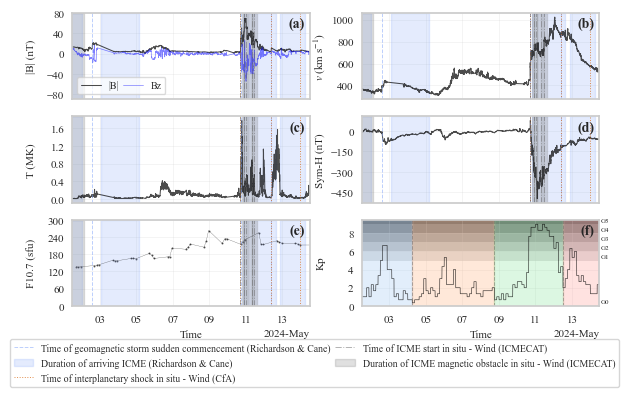

In [186]:
df = dfs['Swarm A'].copy()
plot_sw_conditions(df)

Conditions during the strongest event of the series.

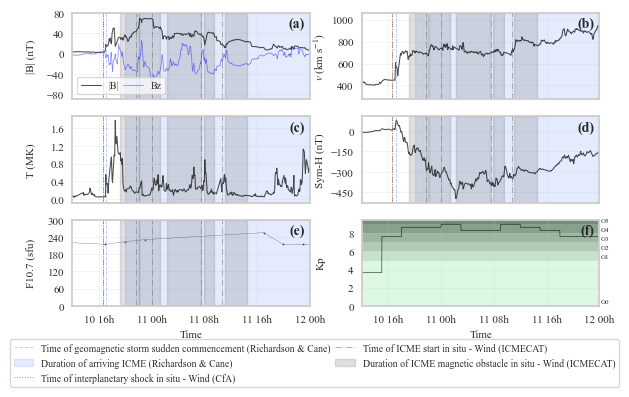

In [187]:
plot_sw_conditions(df, xlims=[pd.to_datetime('2024-05-10 12:00:00'), pd.to_datetime('2024-05-12 00:00:00')])

Timeshifts from L1 to Bow Shock Front

OMNI Timeshift (minutes) between 2024-05-01 12:00:00 - 2024-05-14 11:59:30 had a mean of 39.2 and a standard deviation of 26.0.


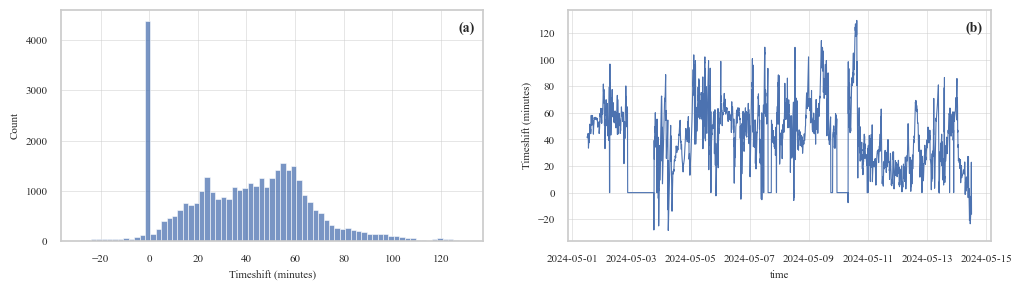

In [177]:
fig, ax = plt.subplots(figsize=(12, 3), nrows=1, ncols=2)
ax = ax.flatten()
df['Timeshift (minutes)'] = df['Timeshift (seconds)'] / 60
df[df['Timeshift (minutes)'] == 0]['Timeshift (minutes)'] = np.nan
df.dropna(inplace=True, axis=1)
sns.histplot(df['Timeshift (minutes)'], ax=ax[0])
sns.lineplot(df['Timeshift (minutes)'], ax=ax[1])
add_panel_labels(ax)
print(f"OMNI Timeshift (minutes) between {df.index[0]} - {df.index[-1]} had a mean of {df['Timeshift (minutes)'].mean():.1f} and a standard deviation of {df['Timeshift (minutes)'].std():.1f}.")

# 3. LEO satellite orbit data

## 3.1 Retrieving the mean orbital parameters.

In [178]:
orbit_params = ['mean_altitude', 'e [-]', 'i [deg]', 'Omega [deg]', 'beta_sun [deg]', 'u_sat [deg]']
print("  Satellite Name & $a - E_R$ (km) & $e$  & $i$ \, \, \, (\\text{degrees}) & $\Omega$ \, \, \, (\\text{degrees}) & Beta Sun  \, (\\text{degrees})  & Pair Phase Difference \, (\\text{degrees}) & $T$ \, (\\text{minutes}) & Sun-Synchronous \\\\")

ordered_sats = sorted(sats, key=lambda x: altitudes[config[x]['name']])
for sat in ordered_sats:
    satellite_name = config[sat]['name']
    df_sat = dfs_lst[satellite_name]

    print(satellite_name, end=' & ')
    for param in orbit_params:
        if param == 'u_sat [deg]' and satellite_name in mean_pair_phase_diffs.keys():
            print(f'{mean_pair_phase_diffs[satellite_name]:.2f}', end=' & ')
        elif param == 'e [-]':
            print(f'{df_sat[param].mean():.5f}', end=' & ')
        else:
            print(f'{df_sat[param].mean():.2f}', end=' & ')

    T = 2 * np.pi * np.sqrt((df_sat['a [m]']//1000)**3 / 398600.4418) / 60
    print(f'{T.mean():.2f}', end=' & ')

    if 'Sentinel' in satellite_name:
        print('yes')
    else:
        print("no")

    print('\\\\')
    print('\hline')


  Satellite Name & $a - E_R$ (km) & $e$  & $i$ \, \, \, (\text{degrees}) & $\Omega$ \, \, \, (\text{degrees}) & Beta Sun  \, (\text{degrees})  & Pair Phase Difference \, (\text{degrees}) & $T$ \, (\text{minutes}) & Sun-Synchronous \\
Swarm A & 474.45 & 0.00158 & 87.29 & -22.74 & -60.21 & -0.44 & 93.93 & no
\\
\hline
Swarm C & 474.45 & 0.00158 & 87.29 & -24.14 & -61.20 & 0.44 & 93.93 & no
\\
\hline
GRACE-FO C & 482.80 & 0.00143 & 88.86 & -55.67 & -68.69 & 1.52 & 94.10 & no
\\
\hline
GRACE-FO D & 482.79 & 0.00143 & 88.86 & -55.67 & -68.69 & -1.52 & 94.10 & no
\\
\hline
Swarm B & 509.94 & 0.00161 & 87.68 & -145.82 & 11.11 & 180.29 & 94.66 & no
\\
\hline
Sentinel 1A & 699.99 & 0.00143 & 98.27 & 136.38 & 64.66 & 180.11 & 98.61 & yes
\\
\hline
Sentinel 2A & 793.28 & 0.00138 & 98.52 & -156.45 & 17.72 & 179.80 & 100.57 & yes
\\
\hline
Sentinel 2B & 793.28 & 0.00139 & 98.52 & -156.46 & 17.72 & -179.80 & 100.57 & yes
\\
\hline
Sentinel 3A & 806.95 & 0.00137 & 98.59 & -163.90 & 24.51 & -138.78 & 

## 3.2 Propagating and visualizing ground tracks at a specific time

Choosing the peak time of the extreme (G5) event for plotting the groundtracks.

In [179]:
target_time = "2024-05-11 02:15:00"

sat_objects = {}
for key in dfs_lst:
    df = dfs_lst[key]
    row = df[df.index == target_time].iloc[0]

    orbit = Orbit.from_classical(
        Earth,
        a=row['a [m]'] * u.m,
        ecc=row['e [-]'] * u.one,
        inc=row['i [deg]'] * u.deg,
        raan=row['Omega [deg]'] * u.deg,
        argp=row['omega [deg]'] * u.deg,
        nu = (row['u_sat [deg]'] - row['omega [deg]']) * u.deg,
        epoch=Time(row.name)
    )

    sat = EarthSatellite(orbit, key)
    sat_objects[key] = sat

/Users/vanessa/PhD/Dev/SELAnalysis/SpaceWeatherImpact/workflow/envs/swi_venv/lib/python3.9/site-packages/astropy/units/decorators.py:313: UserWarning:

Wrapping true anomaly to -π <= nu < π



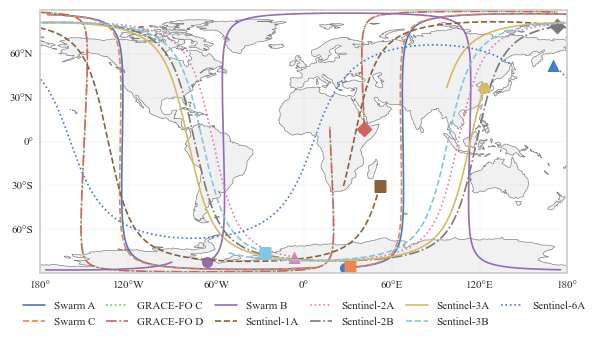

In [180]:
plot_orbit_cartopy(sat_objects, target_time, label='all-cartopy')

Orthographic projection for easier visualization of the ground tracks during the event.

In [181]:
plot_orbit_plotly(sat_objects, target_time, projection_type='orthographic', save=False)

# 4. Removing dominant periods in the semi-major axis data via STL Decomposition

In [182]:
sat = 'Swarm A'
dataframe = dfs[sat].copy()

## 4.1 Intermediate power spectral density of Swarm A after subsequent removals of dominant periods.

Reproducing the same approach from src.preprocessing.preprocess_dataset.PODPreprocessor to exemplify intermediate power spectral density of Swarm A after subsequent removals of dominant periods.

In [183]:
column = 'a [m]'
steps = 4

to_plot = []
already_processed = []

pod_preprocessor = PODPreprocessor()
_, periods, spectrum = pod_preprocessor.get_period(dataframe, column, 'linear', already_processed, debug=True)
best_period, best_spectrum = int(periods[0]), spectrum[0]

print(f"Best period: {best_period * 0.5} minutes")
to_plot.append((periods * 0.5, spectrum, best_period * 0.5, best_spectrum))

for i in range(1, steps+1):
    already_processed.append(best_period)
    stl = STL(dataframe[column], period=best_period, robust=True)
    res_stl = stl.fit()

    dataframe['trend'] = res_stl.trend
    dataframe[f'seasonal_{i}'] = res_stl.seasonal
    dataframe['residual'] = res_stl.resid
    dataframe['unresolved'] = dataframe['trend'] + dataframe['residual']

    column = 'unresolved'
    pod_preprocessor = PODPreprocessor()
    best_periods, periods, spectrum = pod_preprocessor.get_period(dataframe, column, 'linear', already_processed, debug=True)
    best_period, best_spectrum = int(periods[0]), spectrum[0]
    print(f"Best period: {best_period * 0.5} minutes")
    to_plot.append((periods * 0.5, spectrum, best_period * 0.5, best_spectrum))

TypeError: get_period() got an unexpected keyword argument 'debug'

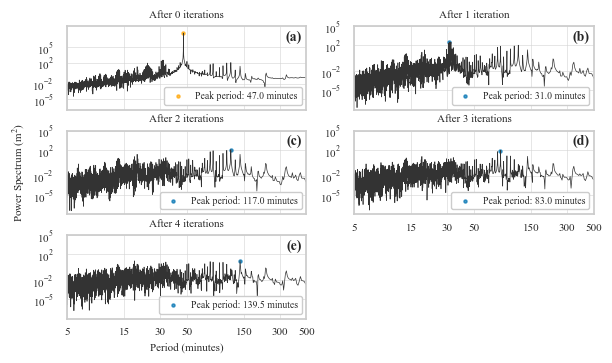

In [50]:
plot_spectra_for_decomposition(to_plot, sat)

## 4.2 Final decomposition of the semi-major axis data

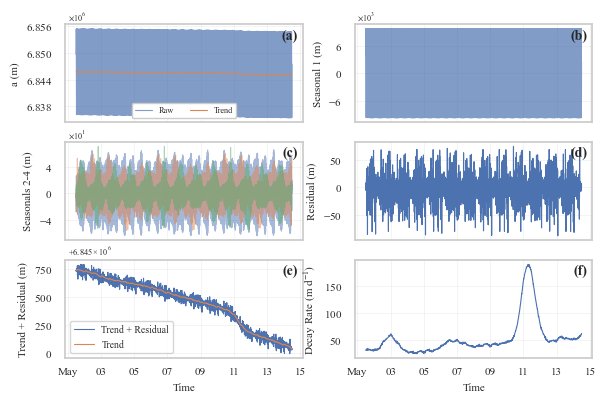

In [51]:
plot_decomposed_data(dataframe, sat)

# 5. Atmospheric response time estimation

## 5.1 Correlation analysis of the orbital decay rate with solar wind |B| under negative Bz conditions

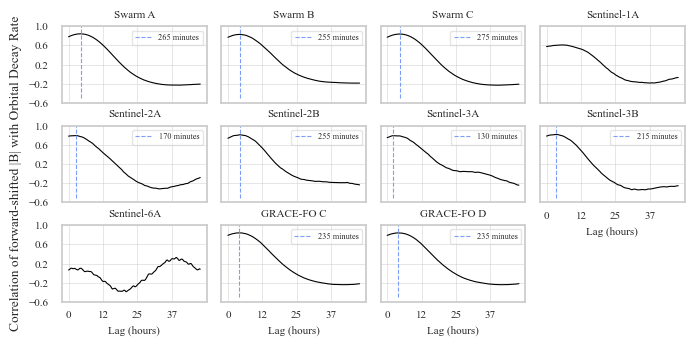

In [52]:
plot_correlations_vs_lag(best_shifts_combined, 'All', '0', suptitle=False, col_cor='|avg B|', method='pearson', show=True, cor_thr=0.7)

## 5.2 Annotations of decay disturbance strength, to compute the above analysis per strength.

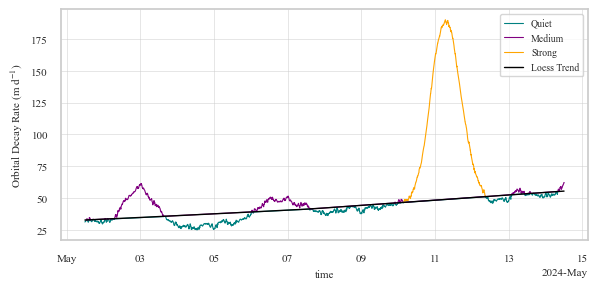

In [53]:
satellite = 'Swarm A'
activity_levels = pd.read_csv(f"{RESULTS_PATH}/shifts/activity_levels_{satellite}.csv")
# have to rename since in the past I saved with the (bad) name below
activity_levels.rename(columns={'Orbital Decay (m) - without maneuvers': target}, inplace=True)
activity_levels.set_index('time', inplace=True)
activity_levels.index = pd.to_datetime(activity_levels.index)

fig_width = 6.8
fig_height = 3
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))

sns.lineplot(data=activity_levels, x=activity_levels.index, y=target, hue='activity_level', palette=['teal', 'purple', 'orange'], legend='full', ax=ax1)
sns.lineplot(data=activity_levels, x=activity_levels.index, y='lowess_decay_trend', color='black', label='Loess Trend', linewidth=1, ax=ax1)

ax1.set_ylabel("Orbital Decay Rate (m d$^{-1}$)")

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator, show_offset=True)
ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(formatter)

plt.savefig(f'{RESULTS_PATH}/disturbance_annotations/orbit_disturbance_annotation_{satellite}.pdf', dpi=600, bbox_inches='tight')
plt.show()

# 6. Orbit decay during May 1-14, 2024: Statistics and comparisons across satellites

## 6.1 Orbital decay rates for all satellites

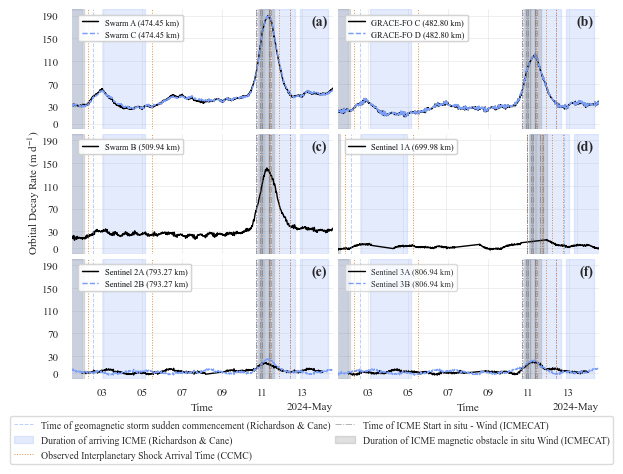

In [54]:
satellites_by_plot = {
    '0': ['Swarm A', 'Swarm C'],
    '1': ['GRACE-FO C', 'GRACE-FO D'],
    '2': ['Swarm B'],
    '3': ['Sentinel 1A'],
    '4': ['Sentinel 2A', 'Sentinel 2B'],
    '5': ['Sentinel 3A', 'Sentinel 3B'],
}
plot_orbit_decay(satellites_by_plot)

## 6.2 Statistics

In [55]:
dfa = df_all_stats.copy()
dfa = dfa.pivot(index='Satellite', columns='Function', values=target)
altitudes = {s['name']: s['altitude'] for s in config.values()}
dfa = dfa.sort_index(key=lambda x: x.map(altitudes))
dfa = dfa[['min', 'median', 'max', 'mean', 'std']]

print(tabulate(dfa, headers='keys', tablefmt='latex', floatfmt=".2f"))

\begin{tabular}{lrrrrr}
\hline
 Satellite   &   min &   median &    max &   mean &   std \\
\hline
 Swarm A     & 25.04 &    44.92 & 190.09 &  53.74 & 34.02 \\
 Swarm C     & 25.27 &    45.16 & 190.83 &  53.93 & 34.07 \\
 GRACE-FO C  & 12.16 &    30.01 & 121.58 &  35.20 & 21.49 \\
 GRACE-FO D  & 12.23 &    30.27 & 122.08 &  35.44 & 21.56 \\
 Swarm B     & 14.57 &    26.76 & 141.35 &  35.70 & 25.76 \\
 Sentinel 1A & -3.09 &     3.87 &  15.34 &   4.41 &  3.78 \\
 Sentinel 2A & -3.08 &     2.86 &  18.82 &   3.72 &  4.03 \\
 Sentinel 2B & -3.24 &     2.13 &  25.32 &   3.32 &  5.00 \\
 Sentinel 3A & -3.33 &     1.98 &  20.85 &   3.16 &  4.60 \\
 Sentinel 3B & -3.56 &     2.21 &  23.79 &   3.40 &  4.86 \\
 Sentinel 6A & -8.50 &     0.22 &   8.64 &   0.17 &  2.87 \\
\hline
\end{tabular}


## 6.3 Max decay rates and relative increases in May 1-14, 2024, across all satellites.

Relative increase as max-to-median ratio, i.e. max during extreme (G5) storm vs median.

               Satellite    MaxDecay  MaxToMedianRatio    Altitude
Satellite                                                         
Swarm C          Swarm C  190.832020          4.226127  484.458455
Swarm A          Swarm A  190.087198          4.231276  484.461349
GRACE-FO D    GRACE-FO D  122.079180          4.033592  492.714632
GRACE-FO C    GRACE-FO C  121.580288          4.051186  492.720112
Swarm B          Swarm B  141.354453          5.282486  519.808562
Sentinel 1A  Sentinel-1A   15.340784          3.960299  709.235089
Sentinel 2B  Sentinel-2B   25.323866         11.893911  802.394467
Sentinel 2A  Sentinel-2A   18.824848          6.572514  802.406803
Sentinel 3A  Sentinel-3A   20.851294         10.514491  816.045313
Sentinel 3B  Sentinel-3B   23.793188         10.764774  816.049476


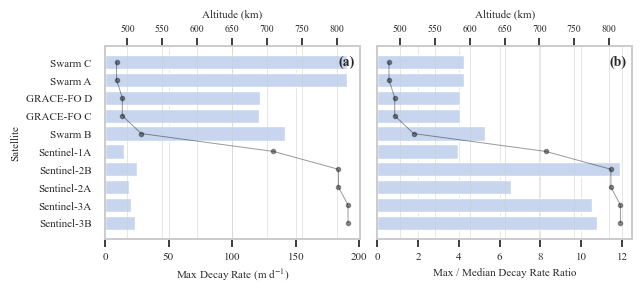

In [56]:
plot_relative_orbit_decay_rate_increases()

## 6.4 Orbital decay rates and altitude increase rates for satellites that maneuvered

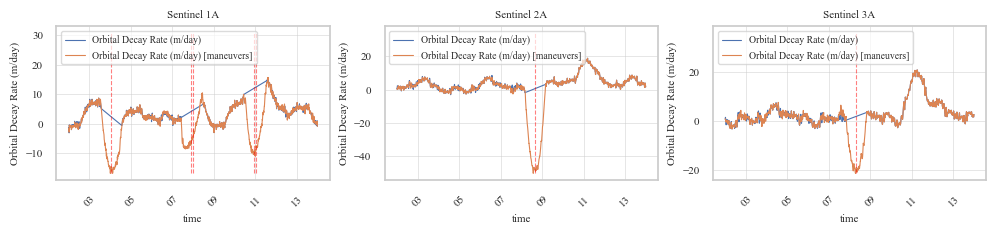

In [57]:
maneuvers = pd.read_csv(f"{BASE_PATH}/maneuvers/maneuvers.csv")

sats_with_maneuvers = maneuvers['Satellite'].unique()
fig, ax = plt.subplots(figsize=(12, 2), nrows=1, ncols=len(sats_with_maneuvers))

for i, sat in enumerate(sats_with_maneuvers):
    mans_sat = maneuvers[maneuvers['Satellite'] == sat].copy()

    mans_sat['Maneuver Start'] = pd.to_datetime(mans_sat['Maneuver Start'])
    mans_sat['Maneuver End'] = pd.to_datetime(mans_sat['Maneuver End'])

    df = dfs[sat].copy()
    sns.lineplot(df[target], label=target, ax=ax[i])
    sns.lineplot(df[target_with_maneuvers], label=target_with_maneuvers, ax=ax[i])

    for k, man in mans_sat.iterrows():
        if man['Maneuver Start'] in df.index:
            ax[i].vlines(man['Maneuver Start'], color='red', ymin=df[target_with_maneuvers].min(), ymax=df[target_with_maneuvers].max()+15, label='Maneuver Start' if k == 0 else None, alpha=0.5, linestyle='--')

    ax[i].xaxis.set_major_locator(mdates.AutoDateLocator())
    ax[i].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator(), show_offset=False))
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_title(sat)
    ax[i].legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.7)

plt.show()

# 7. Timing analysis of the maximum decay rate with respect to minimum Bz and minimum Sym-H

Timing analysis using min Bz and min Sym-H as reference points for the maximum decay rate, to compare with literature

## 7.1 Getting the min Bz, min Sym-H, max decay rate time delays.

In [58]:
results = []
results_bz = []
time_ranges_of_interest = get_time_ranges_for_geomagnetically_disturbed_intervals()

for sat in dfs.keys():
    data1 = dfs[sat]

    for start, end in time_ranges_of_interest:
        time_mask = (data1.index >= start) & (data1.index <= end)
        decay_series = data1.loc[time_mask][target]
        symh_series = data1.loc[time_mask]['SymH (Omni)']
        bz_series = data1.loc[time_mask]['Bz GSE']

        if decay_series.empty or symh_series.empty:
            continue  # skip if no data in time range

        min_bz_val = bz_series.min()
        min_Bz_time = bz_series.idxmin()

        symh_after_min_Bz = symh_series.loc[min_Bz_time:]

        min_symh_val = symh_after_min_Bz.min()
        min_symh_time = symh_after_min_Bz.idxmin()

        # only consider decay values AFTER min_symh_time
        decay_after_symh = decay_series.loc[decay_series.index >= min_symh_time]
        decay_after_bz = decay_series.loc[decay_series.index >= min_Bz_time]

        # skip if there's no decay data after min SymH
        if decay_after_symh.empty:
            continue

        max_decay_rate = decay_after_symh.max()
        max_decay_time = decay_after_symh.idxmax()

        max_decay_rate_bz = decay_after_bz.max()
        max_decay_time_bz = decay_after_bz.idxmax()

        median_decay_period = decay_series.median()

        time_diff = max_decay_time - min_symh_time
        time_diff_bz = max_decay_time_bz - min_Bz_time

        results.append({
            "Satellite": sat,
            "Start": start,
            "End": end,
            "Max Kp" :  data1.loc[time_mask]['Kp (LASP)'].max(),
            "Min SymH": min_symh_val,
            "Time of Min SymH": min_symh_time,
            "Median Decay": median_decay_period,
            "Max Decay After Min SymH": max_decay_rate,
            "Time of Max Decay": max_decay_time,
            "Time Difference": time_diff,
            "Altitude" :  int(data1.loc[time_mask]['mean_altitude'].mean()),
            "Storm Level" :  classify_kp(data1.loc[time_mask]['Kp (LASP)'].max())
        })

        results_bz.append({
            "Satellite": sat,
            "Start": start,
            "End": end,
            "Max Kp" :  data1.loc[time_mask]['Kp (LASP)'].max(),
            "Min SymH": min_symh_val,
            "Min Bz" : min_bz_val,
            "Time of Min Bz": min_Bz_time,
            "Median Decay": median_decay_period,
            "Max Decay After Min Bz": max_decay_rate,
            "Time of Max Decay": max_decay_time_bz,
            "Time Difference": time_diff_bz,
            "Altitude" :  int(data1.loc[time_mask]['mean_altitude'].mean()),
            "Storm Level" :  classify_kp(data1.loc[time_mask]['Kp (LASP)'].max())
        })

timing_summary_df = pd.DataFrame(results)
timing_summary_df["Time Difference (hours)"] = timing_summary_df["Time Difference"].dt.total_seconds() / 60 / 60

timing_summary_df_bz = pd.DataFrame(results_bz)
timing_summary_df_bz["Time Difference (hours)"] = timing_summary_df_bz["Time Difference"].dt.total_seconds() / 60 / 60

In [59]:
results_symh = []
results_bz = []
time_ranges_of_interest = get_time_ranges_for_geomagnetically_disturbed_intervals(extend_end=False)
for sat, data1 in dfs.items():
    for start, end in time_ranges_of_interest:

        out_symh = compute_min_bz_max_decay_timings(data1, start, end, target, mode="symh")
        if out_symh:
            out_symh["Satellite"] = sat
            results_symh.append(out_symh)

        out_bz = compute_min_bz_max_decay_timings(data1, start, end, target, mode="bz")
        if out_bz:
            out_bz["Satellite"] = sat
            results_bz.append(out_bz)

In [60]:
timing_summary_df = pd.DataFrame(results_symh)
timing_summary_df["Time Difference (hours)"] = (
    timing_summary_df["Time Difference"].dt.total_seconds() / 3600
)

timing_summary_df_bz = pd.DataFrame(results_bz)
timing_summary_df_bz["Time Difference (hours)"] = (
    timing_summary_df_bz["Time Difference"].dt.total_seconds() / 3600
)

## 7.2 Printing delays used in manuscript to explain chain of events.

In [ ]:
for (start, end), data_bz in timing_summary_df_bz.groupby(['Start', 'End'], sort=True):
    data_symh = timing_summary_df[
        (timing_summary_df['Start'] == start) &
        (timing_summary_df['End'] == end)
    ]

    swarm_A_bz = data_bz[data_bz['Satellite'] == 'Swarm A']
    swarm_A_symh = data_symh[data_symh['Satellite'] == 'Swarm A']

    if swarm_A_bz.empty or swarm_A_symh.empty:
        continue

    # Bz timing
    h1 = swarm_A_bz['Time Difference (hours)'].iloc[0]
    hh_mm1 = f"{int(h1):02d}h {int((h1 - int(h1)) * 60):02d}m"

    # SymH timing
    h2 = swarm_A_symh['Time Difference (hours)'].iloc[0]
    hh_mm2 = f"{int(h2):02d}h {int((h2 - int(h2)) * 60):02d}m"

    print(
        f"Minimum $B_z$ and minimum Sym-H occur {hh_mm1} and {hh_mm2}, respectively, "
        f"before the maximum decay (of {swarm_A_symh['Max Decay'].iloc[0]:.2f} $m\\,\\text{{day}}^{{-1}}$)"
    )

    print(swarm_A_symh['Time of Max Decay'].iloc[0])

## 7.3 Bonus: min Bz max decay rate timings for all satellites

This content is not included in the manuscript, except for the manually verified case of Swarm A, because of potential spurious results in the case of double peak events (e.g. second event) or previously-disturbed geomagnetic field (e.g. last two events).

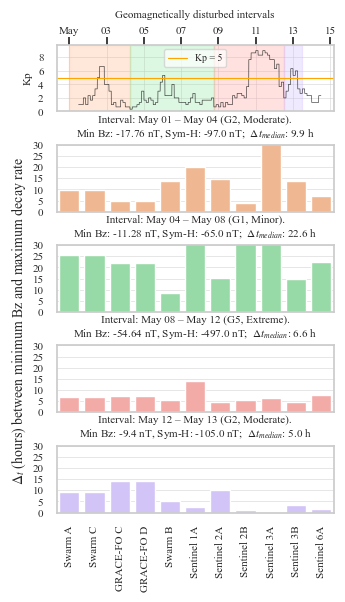

In [67]:
plot_min_bz_to_max_decay_timing(timing_summary_df_bz)

# 8. Propagation Time Estimates

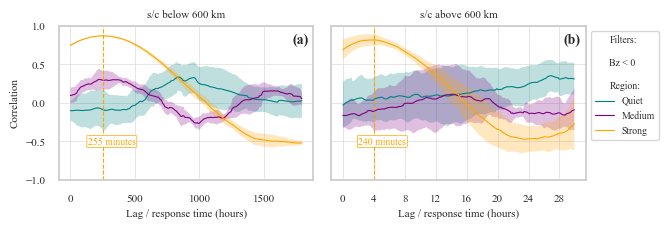

In [63]:
plot_aggregated_satellites_correlation_spread_all_regions(best_shifts_combined, pal=['teal', 'purple', 'orange'], regions=['Quiet', 'Medium', 'Strong'], show=True)